# Stream and process SMAP L4 data via NASA earthaccess 
In this example, we stream 3-houry Level 4 SMAP soil moisture data, subset to a region, and stack multiple dates to create a data cube.

### Compute

This code took around 3 minutes to run for 33 (3-hourly) timesteps and used around 6GB RAM.

### Acknowledgements

This code was contributed by Taryn Anderson and published for the [SARP snippets](https://github.com/NASA-SARP/2026-Coding-Alex/tree/main/snippets) by Alex Saunders.

In [1]:
# Install earthaccess
# !pip install earthaccess
# !conda install -c conda-forge earthaccess

In [7]:
import earthaccess
import xarray as xr
import rioxarray
from pathlib import Path
from datetime import datetime, date
import matplotlib.pyplot as plt
import psutil
import os
import warnings
import gc
import geopandas as gpd
from shapely import box
warnings.filterwarnings("ignore")

In [8]:
# Login using your credentials - your user name and password for NASA EarthData
earthaccess.login()

## Dataset search to get the collection short name

In [9]:
dataset_results = earthaccess.search_datasets(
    keyword="SMAP L4",
    downloadable=True,
    cloud_hosted=True)

# Briefly show the search results
print(f'Dataset search returned {len(dataset_results)} results')
print('\nShowing the first result:\n', dataset_results[0].summary())
print('\nShowing the short names for all results:\n', [dataset_results[i].summary()['short-name'] for i in range(len(dataset_results))])

Dataset search returned 29 results

Showing the first result:
 {'short-name': 'SPL4SMGP', 'concept-id': 'C3480440870-NSIDC_CPRD', 'version': '008', 'file-type': "[{'FormatType': 'Native', 'Format': 'HDF5', 'FormatDescription': 'HTTPS 1.1 GB'}]", 'get-data': ['https://search.earthdata.nasa.gov/search/granules?p=C3480440870-NSIDC_CPRD', 'https://cmr.earthdata.nasa.gov/virtual-directory/collections/C3480440870-NSIDC_CPRD', 'https://nsidc.org/data/data-access-tool/SPL4SMGP/versions/8/', 'https://appeears.earthdatacloud.nasa.gov/', 'https://earthaccess.readthedocs.io/en/stable/'], 'cloud-info': {'Region': 'us-west-2', 'S3BucketAndObjectPrefixNames': ['nsidc-cumulus-prod-protected/SMAP/SPL4SMGP/008', 'nsidc-cumulus-prod-public/SMAP/SPL4SMGP/008'], 'S3CredentialsAPIEndpoint': 'https://data.nsidc.earthdatacloud.nasa.gov/s3credentials', 'S3CredentialsAPIDocumentationURL': 'https://data.nsidc.earthdatacloud.nasa.gov/s3credentialsREADME'}}

Showing the short names for all results:
 ['SPL4SMGP', '

## Define collection and search parameters

In [26]:
# Collection and group and name for the variable of interest

# Option for SPL4SMGP - geophyical data
collection_dict = {'short_name': 'SPL4SMGP',
                   'group_name': 'Geophysical_Data',
                   'var_name': 'sm_surface'}

# # Option for SPL4SMAU - analysis data assimilation
# collection_dict = {'short_name': 'SPL4SMAU',
#                    'group_name': 'Analysis_Data',
#                    'var_name': 'sm_surface_analysis'}

# Time and region of interest
start_date, end_date = "2022-12-25", "2022-12-28"
xmin, ymin, xmax, ymax = -124, 32, -114, 42

In [27]:
# Perform earthdata search
results = earthaccess.search_data(
        short_name=collection_dict['short_name'],
        bounding_box=(xmin, ymin, xmax, ymax),
        temporal=(start_date, end_date),
    )
print(f'Search returned {len(results)} results')

Search returned 33 results


In [28]:
# Stream the results
files = earthaccess.open(results)

QUEUEING TASKS | :   0%|          | 0/33 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/33 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/33 [00:00<?, ?it/s]

In [29]:
# If necessary inspect the datatree to find the group_name and var_name
# xr.open_datatree(files[0])

## Define function to open the SMAP data
* Open streamed file and read the soil moisture variable
* Prepare lat/lon and time coordinate values
* Write the CRS using the EASE 2.0 Grid and reproject to EPSG:4326
* Subset to the defined region of interest
* Return a single timestep data array

__Note:__ this code reprojects the SMAP data from the EASE 2.0 grid (EPSG:6933) to EPSG:4326. If you need faster processing, it is likely to be more efficient to leave the SMAP data its native EASE 2.0 grid (EPSG:6933) projection, and instead convert the region-of-interest bounding coordinates to the SMAP projection for the spatial subsetting. You could do this using `geopandas`:
```
gdf = gpd.GeoDataFrame(geometry=[box(xmin, ymin, xmax, ymax)], crs=4326).to_crs(6933)
xmin, ymin, xmax, ymax = gdf.total_bounds

```

In [30]:
# Function to open the streamed file, prepare the x,y,t values, reproject to 4326, subset to defined region
def open_smap(file, group_name, var_name, xmin, ymin, xmax, ymax):

    ds = xr.open_dataset(file, engine="h5netcdf", group=group_name)
    ds_xyt = xr.open_dataset(file, engine="h5netcdf")

    da = ds[var_name]
    da["x"] = ds_xyt.x
    da["y"] = ds_xyt.y

    da = (da.expand_dims(time=[ds_xyt.time.values[0]])
            .rio.write_crs("EPSG:6933")
            .rio.reproject("EPSG:4326") # comment out these two lines if you you converted your xmin, ymin, xmax, ymax values to the SMAP projection
            .reset_coords("EASE2_global_projection", drop=True) # comment out these two lines if you you converted your xmin, ymin, xmax, ymax values to the SMAP projection
            .sortby("y")
            .sel(x=slice(xmin, xmax),
                 y=slice(ymin, ymax)))

    return da

## Run the function on the streamed files and create a (x,y,time) data cube

In [31]:
# Run the function on the files and create a list of the opened and preprocessed data array
data_arrays = []
process_start = datetime.now()
for i, file in enumerate(files):
    data_array = open_smap(file, collection_dict['group_name'], collection_dict['var_name'],
                           xmin, ymin, xmax, ymax)
    data_arrays.append(data_array)
    print(f'Completed {i+1} of {len(files)} files', end='\r')

# Concatenate the list of data arrays to create a data cube
data_cube = xr.concat(data_arrays, dim="time")
process_time = datetime.now() - process_start

# Get current RAM usage
process = psutil.Process(os.getpid())
print(f'memory usage {process.memory_info().rss / 1024**3} GB')

# Print time it took for the processing
print(f'Process took {process_time.seconds / 60} minutes')

memory usage 9.67007064819336 GB
Process took 2.4 minutes


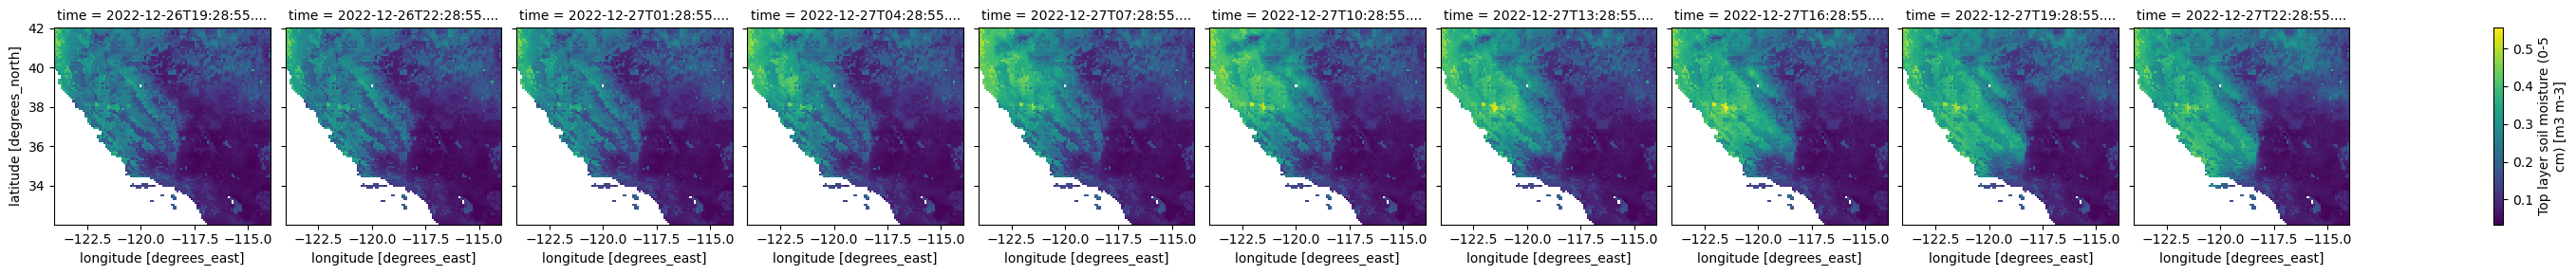

In [34]:
# Quick plot of ten of the 3-hourly timesteps
data_cube.isel(time=slice(15,25)).plot(col='time')

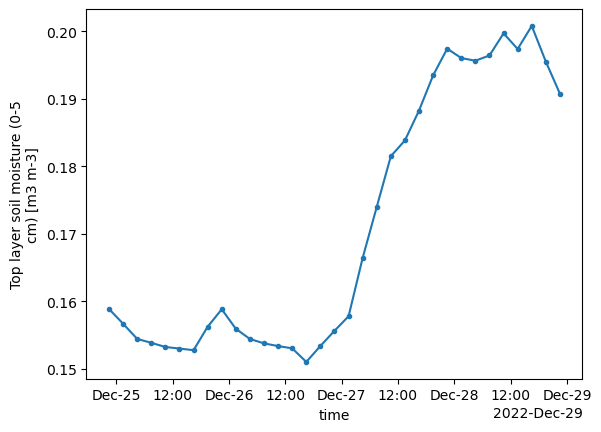

In [35]:
# Extract mean time-series over region
data_cube.mean(dim=['x','y']).plot(marker='.')